# Лабораторная работа №2

**Цель:** обработка кардиологического датасета и решение задачи бинарной классификации по признаку `Healthy_Status`.

В работе используются признаки: Count_subj, rr_interval, p_end, qrs_onset, qrs_end, p_axis, qrs_axis, t_axis.

## 1. Импорт библиотек

In [2]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

DATA_PATH = '5000 строк.xlsx'
FEATURES = ['Count_subj', 'rr_interval', 'p_end', 'qrs_onset', 'qrs_end', 'p_axis', 'qrs_axis', 't_axis']
TARGET = 'Healthy_Status'
BOUNDS = {'rr_interval': (300, 2000), 'p_end': (0, 300), 'qrs_onset': (0, 600), 'qrs_end': (0, 800), 'p_axis': (-180, 180), 'qrs_axis': (-180, 180), 't_axis': (-180, 180)}

plt.rcParams['figure.dpi'] = 140
plt.rcParams['font.family'] = 'DejaVu Sans'

## 2. Загрузка данных и выбор первых 5000 строк

In [3]:
df_raw = pd.read_excel(DATA_PATH)
df = df_raw.iloc[:5000][FEATURES + [TARGET]].copy()
print('Размер выборки:', df.shape)
df.head()

Размер выборки: (5000, 9)


,Count_subj,rr_interval,p_end,qrs_onset,qrs_end,p_axis,qrs_axis,t_axis,Healthy_Status
0,27,659,128,170,258,81,77,79,0
1,93,722,124,162,246,77,75,70,0
2,3,600,130,162,244,79,72,77,1
3,7,659,146,180,254,79,66,69,1
4,2,659,29999,504,590,84,80,77,0


## 3. Очистка данных и первичный анализ

In [4]:
class_dist = df[TARGET].value_counts().sort_index()
outlier_counts = {}
for col, (lo, hi) in BOUNDS.items():
    mask = (df[col] < lo) | (df[col] > hi)
    outlier_counts[col] = int(mask.sum())
    df.loc[mask, col] = np.nan

print('Распределение классов:')
print(class_dist)
pd.DataFrame({'Признак': list(outlier_counts.keys()), 'Количество замен': list(outlier_counts.values())})

Распределение классов:
Healthy_Status
0    4040
1     960
Name: count, dtype: int64


,Признак,Количество замен
0,rr_interval,11
1,p_end,1543
2,qrs_onset,10
3,qrs_end,10
4,p_axis,911
5,qrs_axis,33
6,t_axis,69


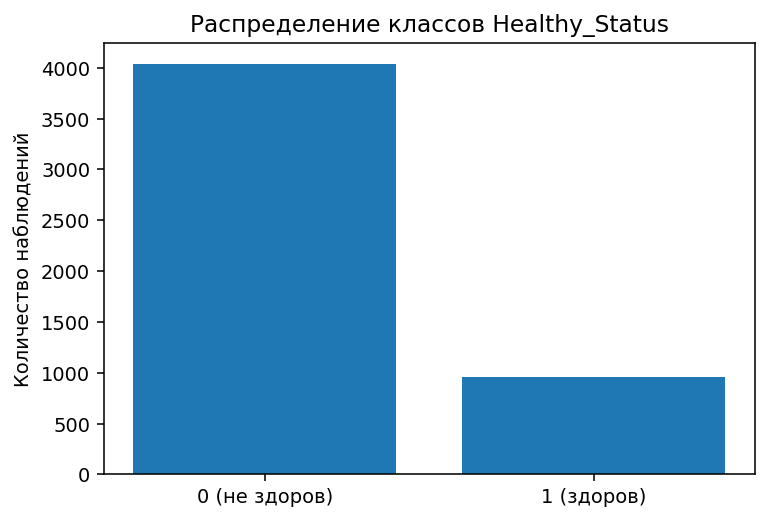

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['0 (не здоров)', '1 (здоров)'], [class_dist.get(0, 0), class_dist.get(1, 0)])
ax.set_title('Распределение классов Healthy_Status')
ax.set_ylabel('Количество наблюдений')
plt.show()

## 4. Разделение на обучающую и тестовую выборки

In [5]:
X = df[FEATURES].copy()
y = df[TARGET].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)

X_train: (4000, 8)
X_test : (1000, 8)


## 5. PCA

In [6]:
prep = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
X_ready = prep.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_ready)
print('Доли объяснённой дисперсии:', pca.explained_variance_ratio_)

Доли объяснённой дисперсии: [0.25540202 0.15373299]


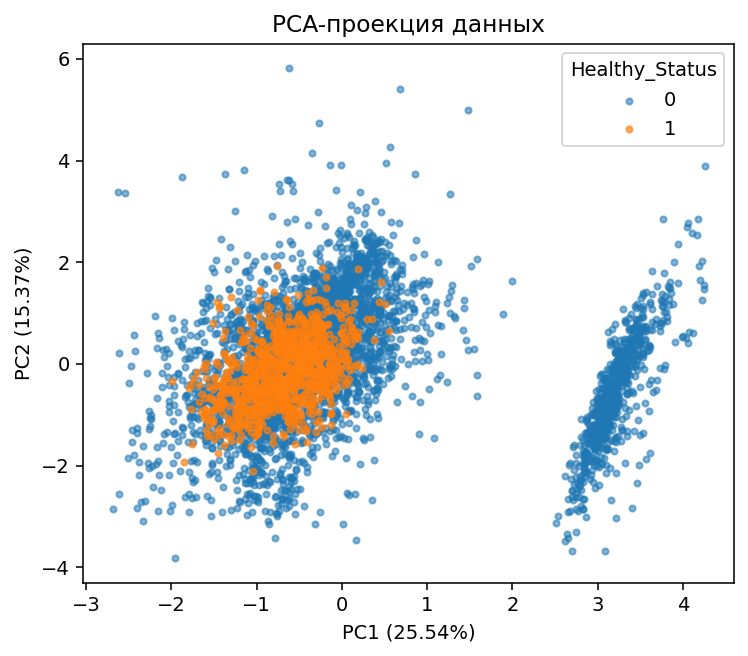

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
mask0 = (y == 0).to_numpy()
mask1 = (y == 1).to_numpy()
ax.scatter(X_pca[mask0, 0], X_pca[mask0, 1], s=10, alpha=0.55, label='0')
ax.scatter(X_pca[mask1, 0], X_pca[mask1, 1], s=10, alpha=0.65, label='1')
ax.set_title('PCA-проекция данных')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}%)')
ax.legend(title='Healthy_Status')
plt.show()

## 6. t-SNE
Для сокращения времени вычислений t-SNE строится на случайной подвыборке из 50 строк.

In [8]:
import sklearn
from sklearn.manifold import TSNE
import numpy as np

idx = np.random.RandomState(42).choice(len(X_ready), size=50, replace=False)
X_tsne_base = X_ready[idx]
y_tsne = y.iloc[idx].reset_index(drop=True)

version = tuple(map(int, sklearn.__version__.split(".")[:2]))

tsne_params = {
    "n_components": 2,
    "random_state": 42,
    "init": "pca",
    "learning_rate": "auto",
    "perplexity": 10,
    "method": "barnes_hut"
}

if version >= (1, 5):
    tsne_params["max_iter"] = 250
else:
    tsne_params["n_iter"] = 250

tsne = TSNE(**tsne_params)
X_tsne = tsne.fit_transform(X_tsne_base)

print("scikit-learn version:", sklearn.__version__)
print("t-SNE result shape:", X_tsne.shape)

scikit-learn version: 1.3.2
t-SNE result shape: (50, 2)


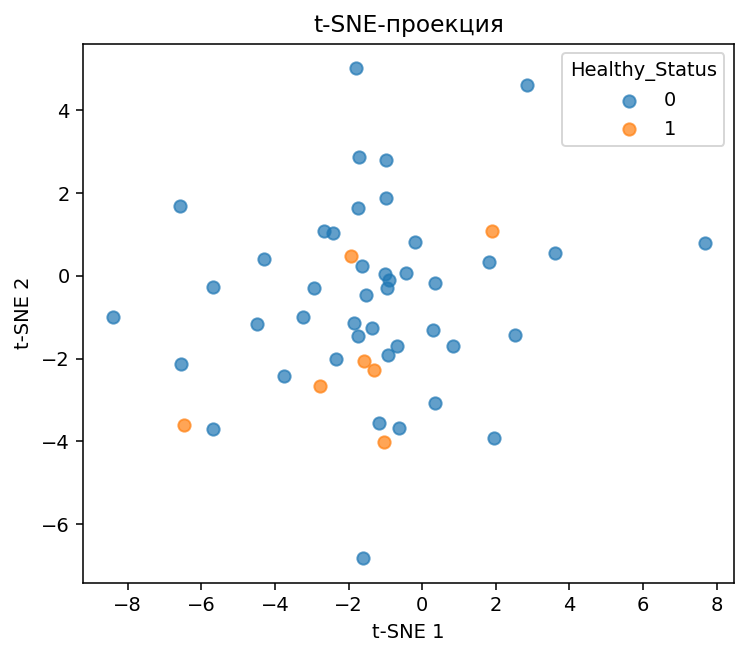

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))

mask0 = (y_tsne == 0).to_numpy()
mask1 = (y_tsne == 1).to_numpy()

ax.scatter(X_tsne[mask0, 0], X_tsne[mask0, 1], s=40, alpha=0.7, label="0")
ax.scatter(X_tsne[mask1, 0], X_tsne[mask1, 1], s=40, alpha=0.7, label="1")

ax.set_title("t-SNE-проекция")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(title="Healthy_Status")
plt.show()

## 7. AutoML-подход
Под AutoML в данной работе понимается автоматизированное сравнение нескольких моделей по единой схеме подготовки данных и одинаковой cross-validation с выбором лучшей модели по F1.

In [11]:
models = {
    'GaussianNB': Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('model', GaussianNB())]),
    'LogisticRegression': Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=2000, random_state=42))]),
    'KNN (k=11)': Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('model', KNeighborsClassifier(n_neighbors=11))]),
    'RandomForest': Pipeline([('imputer', SimpleImputer(strategy='median')), ('model', RandomForestClassifier(n_estimators=250, random_state=42, class_weight='balanced'))]),
    'SVC (RBF)': Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('model', SVC(kernel='rbf', C=1.0, class_weight='balanced', random_state=42))]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []
for name, pipe in models.items():
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1', n_jobs=1)
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    results.append({
        'Модель': name,
        'CV F1': cv_scores.mean(),
        'CV std': cv_scores.std(),
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
    })

results_df = pd.DataFrame(results).sort_values(['CV F1', 'F1'], ascending=False).reset_index(drop=True)
results_df

,Модель,CV F1,CV std,Accuracy,Precision,Recall,F1
0,RandomForest,0.598579,0.024838,0.860,0.646067,0.598958,0.621622
1,SVC (RBF),0.591779,0.015607,0.740,0.420930,0.942708,0.581994
2,GaussianNB,0.573413,0.012281,0.719,0.399549,0.921875,0.557480
3,KNN (k=11),0.487169,0.022240,0.828,0.556818,0.510417,0.532609
4,LogisticRegression,0.142555,0.020889,0.807,0.487805,0.104167,0.171674


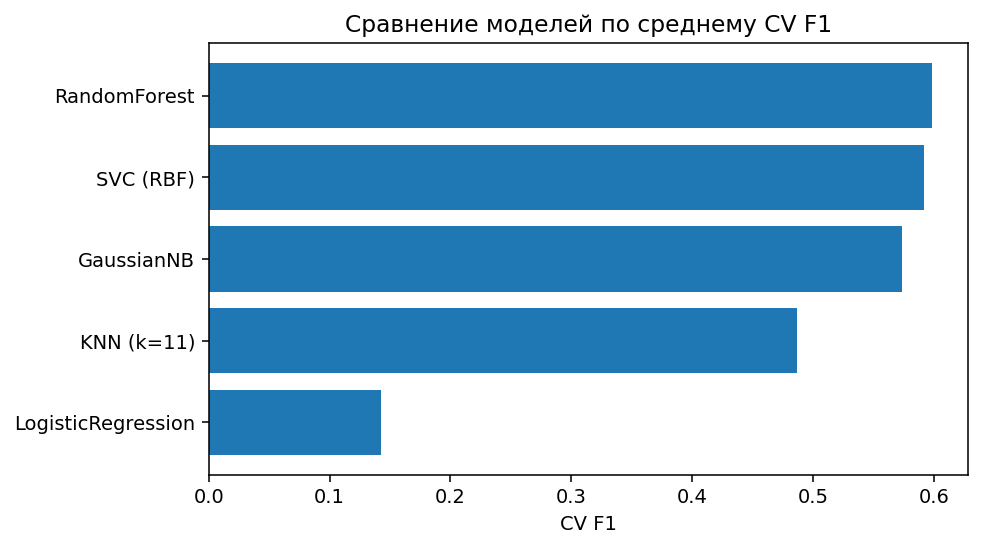

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_df = results_df.sort_values('CV F1', ascending=True)
ax.barh(plot_df['Модель'], plot_df['CV F1'])
ax.set_title('Сравнение моделей по среднему CV F1')
ax.set_xlabel('CV F1')
plt.show()

In [13]:
best_model_name = results_df.iloc[0]['Модель']
best_model = models[best_model_name].fit(X_train, y_train)
y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print('Лучшая модель:', best_model_name)
print(f'Accuracy : {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall   : {rec:.4f}')
print(f'F1       : {f1:.4f}')
print('Confusion matrix:')
print(cm)

Лучшая модель: RandomForest
Accuracy : 0.8600
Precision: 0.6461
Recall   : 0.5990
F1       : 0.6216
Confusion matrix:
[[745  63]
 [ 77 115]]


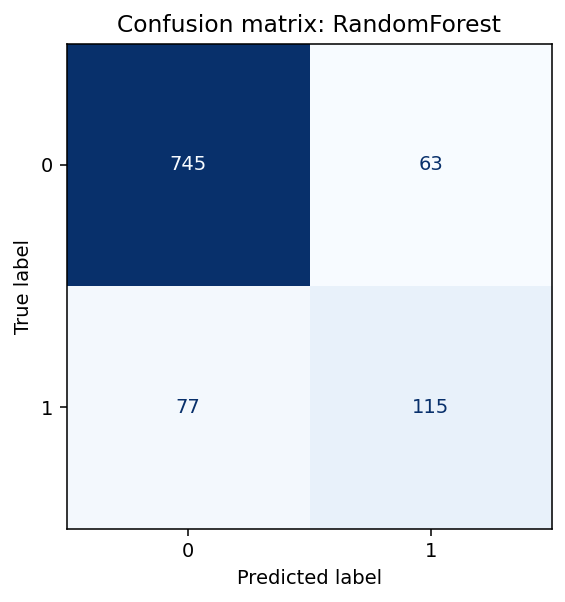

In [14]:
fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1]).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion matrix: {best_model_name}')
plt.show()

## 8. Вывод

Наилучший результат в эксперименте показала модель **RandomForest**. На тестовой выборке она достигла `F1 = 0.6216`. Следовательно, выбранный подход подходит для задачи бинарной классификации признака `Healthy_Status` по числовым параметрам ЭКГ.